In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import os

plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv("../data/wrangled_sol_data.csv", index_col=0, parse_dates=True)
df.columns = [str(col).strip() for col in df.columns]

print(df.shape)
print(df.dtypes)
df.head()

(1197, 11)
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Daily_Return     float64
MA_7             float64
MA_21            float64
Price_Range      float64
Volume_Change    float64
Target             int64
dtype: object


,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Price_Range,Volume_Change,Target
Date,,,,,,,,,,,
2020-09-21,2.782509,3.026940,2.500419,2.870903,19492894,-3.078959,2.880948,3.199595,0.526521,111.481720,1
2020-09-22,2.915519,2.994370,2.668603,2.773688,18556523,4.780215,2.877576,3.131548,0.325767,-4.803653,0
2020-09-23,2.836757,3.065338,2.746303,2.930355,16096650,-2.701476,2.919199,3.068323,0.319035,-13.256109,1
2020-09-24,3.132715,3.251563,2.795647,2.838121,18993326,10.432971,2.953605,3.049531,0.455916,17.995521,1
2020-09-25,3.188612,3.265165,2.911772,3.145544,15935143,1.784299,2.965129,3.032523,0.353393,-16.101356,0


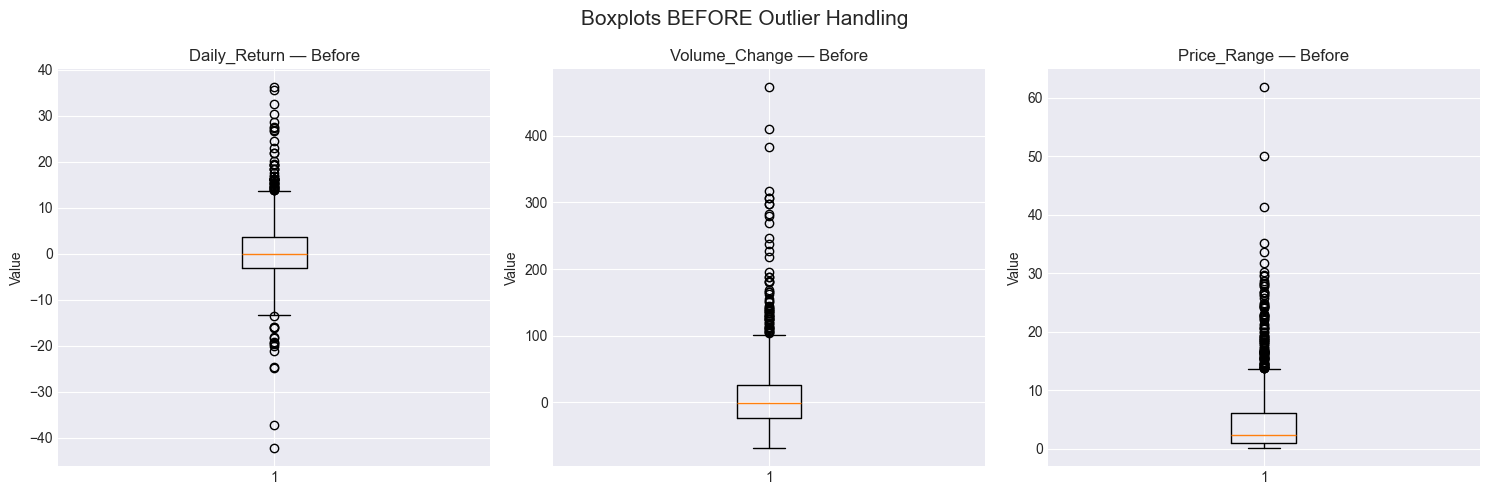

In [4]:
# Columns we'll check for outliers
outlier_cols = ['Daily_Return', 'Volume_Change', 'Price_Range']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col} — Before')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots BEFORE Outlier Handling', fontsize=15)
plt.tight_layout()
plt.savefig('../data/boxplot_before.png', dpi=150)
plt.show()

In [5]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    outlier_report = {}

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        outlier_report[col] = outliers_count

        # Cap outliers (Winsorizing) instead of dropping rows
        # This preserves data size which is important for time series
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print("=== Outlier Report ===")
    for col, count in outlier_report.items():
        print(f"{col:20s}: {count} outliers capped")

    return df_clean

df_clean = remove_outliers_iqr(df, outlier_cols)

print(f"\nShape before: {df.shape}")
print(f"Shape after : {df_clean.shape}") # Same rows — we capped not dropped

=== Outlier Report ===
Daily_Return        : 64 outliers capped
Volume_Change       : 61 outliers capped
Price_Range         : 105 outliers capped

Shape before: (1197, 11)
Shape after : (1197, 11)


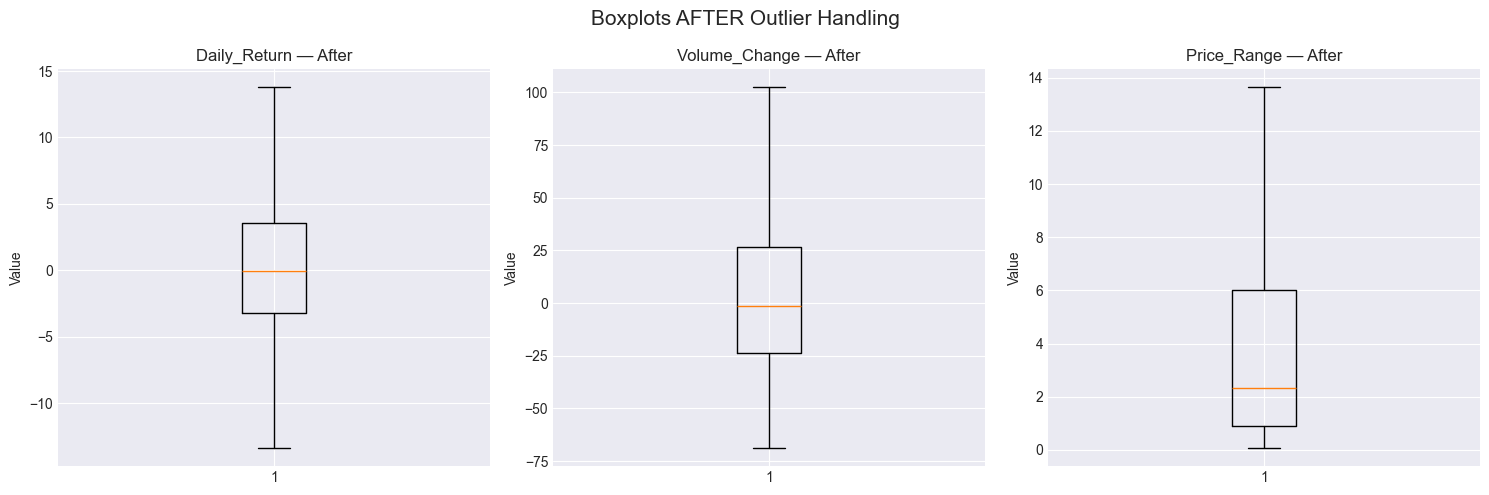

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(f'{col} — After')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots AFTER Outlier Handling', fontsize=15)
plt.tight_layout()
plt.savefig('../data/boxplot_after.png', dpi=150)
plt.show()

In [7]:
# Features we'll feed into ML models
feature_cols = ['Close', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 
                'Price_Range', 'Volume_Change']

target_col = 'Target'

X = df_clean[feature_cols]
y = df_clean[target_col]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1197, 7)
Target shape  : (1197,)

Target distribution:
Target
0    600
1    597
Name: count, dtype: int64


In [8]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print("=== Before Scaling ===")
print(X.describe().round(2))

print("\n=== After Scaling (all values between 0 and 1) ===")
print(X_scaled.describe().round(2))

=== Before Scaling ===
         Close        Volume  Daily_Return     MA_7    MA_21  Price_Range  \
count  1197.00  1.197000e+03       1197.00  1197.00  1197.00      1197.00   
mean     51.20  1.199127e+09          0.41    50.95    50.40         4.10   
std      54.91  1.419874e+09          5.85    54.68    54.17         4.25   
min       1.21  6.139511e+06        -13.39     1.38     1.53         0.07   
25%      19.23  2.787295e+08         -3.20    19.33    19.27         0.91   
50%      30.39  6.968949e+08         -0.02    30.60    30.44         2.34   
75%      60.99  1.708817e+09          3.58    58.64    58.33         6.00   
max     258.93  1.706864e+10         13.77   246.17   232.05        13.64   

       Volume_Change  
count        1197.00  
mean            6.07  
std            40.26  
min           -68.80  
25%           -23.81  
50%            -1.50  
75%            26.66  
max           102.38  

=== After Scaling (all values between 0 and 1) ===
         Close   Volume 

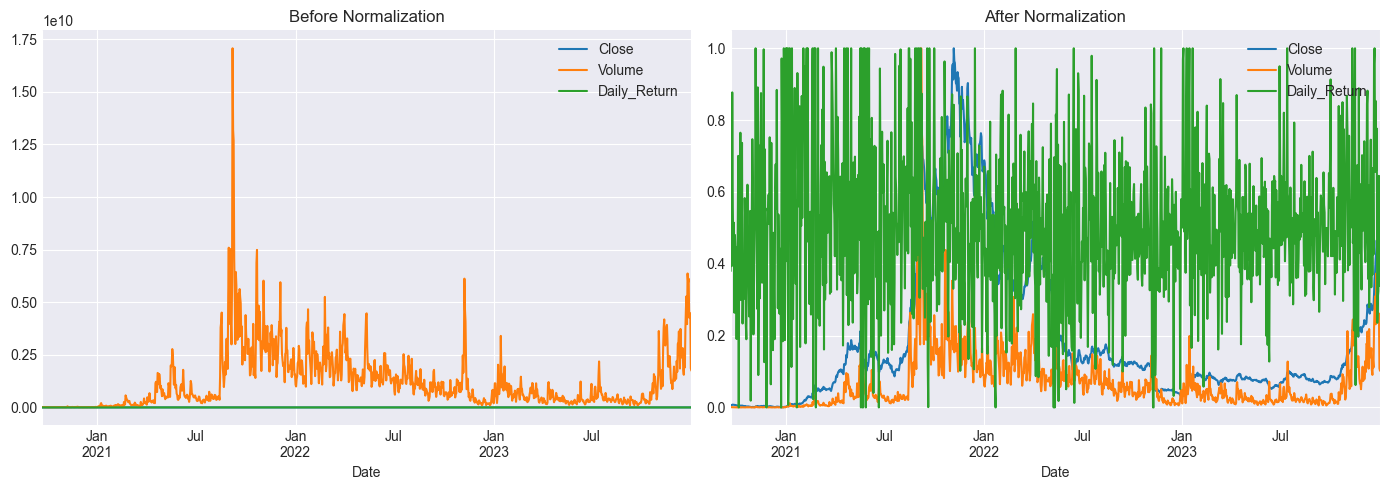

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X[['Close', 'Volume', 'Daily_Return']].plot(ax=axes[0])
axes[0].set_title('Before Normalization')

X_scaled[['Close', 'Volume', 'Daily_Return']].plot(ax=axes[1])
axes[1].set_title('After Normalization')

plt.tight_layout()
plt.savefig('../data/normalization_comparison.png', dpi=150)
plt.show()

In [10]:
# 80% train, 20% test — NO shuffle for time series data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train: (957, 7)
X_test : (240, 7)
y_train: (957,)
y_test : (240,)


In [11]:
os.makedirs("../data", exist_ok=True)

X_train.to_csv("../data/X_train.csv")
X_test.to_csv("../data/X_test.csv")
y_train.to_csv("../data/y_train.csv")
y_test.to_csv("../data/y_test.csv")
X_scaled.to_csv("../data/X_scaled.csv")

# Save scaler for use in Flask API later
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")

print("All processed data saved ✅")
print("Scaler saved to /models ✅")

All processed data saved ✅
Scaler saved to /models ✅
